# Support Vector Machines - Exercise 1

In this exercise, we'll be using support vector machines (SVMs) to build a spam classifier.  We'll start with SVMs on some simple 2D data sets to see how they work.  Then we'll do some pre-processing work on a set of raw emails and build a classifier on the processed emails using a SVM to determine if they are spam or not.

The first thing we're going to do is look at a simple 2-dimensional data set and see how a linear SVM works on the data set for varying values of C (similar to the regularization term in linear/logistic regression).  Let's load the data.
## Exercise 1
#### 1. Load libraries

#### 1. Load the data `ejer_1_data2.mat`

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.io

In [4]:
spam = scipy.io.loadmat('ejer_1_data2.mat')

In [6]:
spam

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Sun Nov 13 14:28:54 2011',
 '__version__': '1.0',
 '__globals__': [],
 'X': array([[0.107143 , 0.60307  ],
        [0.093318 , 0.649854 ],
        [0.0979263, 0.705409 ],
        ...,
        [0.975806 , 0.439474 ],
        [0.989631 , 0.425439 ],
        [0.996544 , 0.414912 ]], shape=(863, 2)),
 'y': array([[1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
    

### Tengo un diccionario con arrays para X y para y. Ahora tengo que crear un dataframe a partir de esa carga de datos.

#### 2. Create a DataFrame with the features and target

In [13]:
# extraigo las variables X e y del diccionario
X = spam['X']
y = spam['y'].ravel() # quito una dimensión para que y sea un vector unidimensional

# creo un dataframe con las variables predictoras y la variable objetivo
df_spam = pd.DataFrame(X, columns=['variable_1', 'variable_2'])

In [14]:
df_spam['variable_objetivo'] = y # añado la variable objetivo al dataframe
df_spam.head() # muestro las primeras filas del dataframe para comprobar que se ha creado correctamente

,variable_1,variable_2,variable_objetivo
0,0.107143,0.603070,1
1,0.093318,0.649854,1
2,0.097926,0.705409,1
3,0.155530,0.784357,1
4,0.210829,0.866228,1


#### 3. Plot a scatterplot with the data

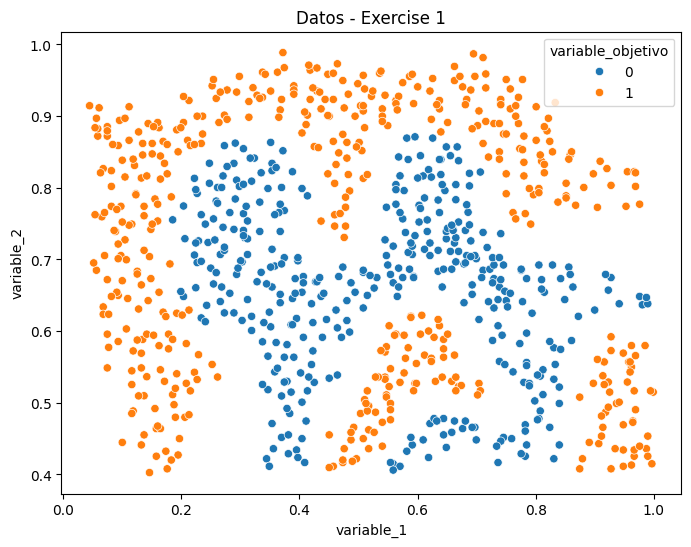

In [15]:
# visualizo los datos con un scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_spam, x='variable_1', y='variable_2', hue='variable_objetivo')
plt.title('Datos - Exercise 1');

### Las clases están mezcladas y entrelazadas, no son linealmente separables.


For this data set we'll build a support vector machine classifier using the built-in RBF kernel and examine its accuracy on the training data.  To visualize the decision boundary, this time we'll shade the points based on the predicted probability that the instance has a negative class label.  We'll see from the result that it gets most of them right.

#### 4. Declare a SVC with this hyperparameters
```Python
SVC(C=100, gamma=10, probability=True)
```


In [17]:
# importo la librería para el modelo SVC
from sklearn.svm import SVC

# creo el modelo SVC con los hiperparámetros C=100 (poco margen de error permitido), 
# gamma=10 (el kernel RBF influye mucho en puntos cercanos) y 
# probability=True (necesario para poder sacar probabilidades después)
svc = SVC(C=100, gamma=10, probability=True)

#### 5. Fit the classifier and get the score

In [18]:
svc.fit(X, y)
print('Score:', svc.score(X, y))

Score: 0.9698725376593279


### Este resultado es muy alto, pero tiene trampa. Está evaluando sobre los mismos datos con los que entrenó, así que es normal que salga tan alto. Esto es overfitting de manual.

#### 6. Plot the scatter plot and probability of predicting 0 with a [sequential color](https://matplotlib.org/3.1.1/tutorials/colors/colormaps.html)

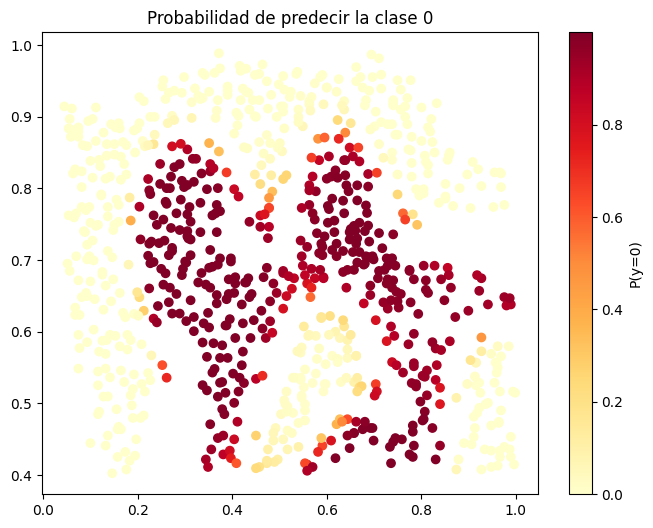

In [24]:
# saco las probabilidades de pertenencia a la clase 0 para cada punto del dataset
prob_clase_0 = svc.predict_proba(X)[:, 0]

# creo un scatter plot donde el color de cada punto representa la probabilidad de pertenencia a la clase 0
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df_spam['variable_1'], df_spam['variable_2'], c=prob_clase_0, cmap='YlOrRd')
plt.colorbar(scatter, label='P(y=0)')
plt.title('Probabilidad de predecir la clase 0');

### En este gráfico, los puntos rojo oscuro significan alta probabilidad de ser clase 0, mientras que los puntos amarillo claro significan que probabilidad baja de ser clase 0. Además, el gráfico coincide con el scatter anterior. Esto significa que el modelo ha conseguido identificar qué zona del espacio pertenece a cada clase, aunque estén mezcladas.


#### Grid search

### Primero hago un RandomizedSearch

In [ ]:
# importo la librería
from sklearn.model_selection import RandomizedSearchCV

# defino los parámetros del SVC
param_dist = {
    'C': [0.1, 1, 10, 100, 1000], # cuanto mayor es C, menos margen de error se permite
    'gamma': [0.001, 0.01, 0.1, 1, 10], # cuanto mayor es gamma, más influencia tienen los puntos cercanos al punto a clasificar
    'kernel': ['linear', 'poly', 'rbf'] # tipos de kernel a probar: lineal, polinómico y RBF
}

# creo el RandomizedSearchCV con el modelo SVC, los parámetros, 20 iteraciones, validación cruzada de 5 folds y métrica de evaluación 'accuracy'
random_search = RandomizedSearchCV(SVC(probability=True), 
                                   param_distributions=param_dist,
                                   n_iter=20, 
                                   cv=5, 
                                   scoring='accuracy',
                                   random_state=42)

# entreno el RandomizedSearchCV probando todas las combinaciones de hiperparámetros
random_search.fit(X, y)

# muestro los mejores parámetros encontrados y el mejor score obtenido
print('Mejores parámetros:', random_search.best_params_)
print('Mejor score:', random_search.best_score_)

Mejores parámetros: {'kernel': 'rbf', 'gamma': 10, 'C': 10}
Mejor score: 0.7875789756687728


### Antes teníamos un score de 96 %, pero esto se debía a que se estaba evaluando sobre los mismos datos de entrenamiento. Este 78 % es más fiel, ya que sale de entrenar a una parte de los datos y evaluar con otra que no ha visto. Por tanto, el 78 % es el score real del modelo. El 96 % era overfitting.


In [27]:
# importo la librería para GridSearchCV
from sklearn.model_selection import GridSearchCV

# defino los parámetros
param_grid = {
    'C': [5, 10, 50, 100], # cuanto mayor es C, menos margen de error se permite
    'gamma': [5, 10, 20, 50], # cuanto mayor es gamma, más influencia tienen los puntos cercanos al punto a clasificar
    'kernel': ['rbf'] # como el mejor kernel encontrado en el RandomizedSearchCV fue el RBF, solo pruebo ese kernel
}

# creo el GridSearchCV con el modelo SVC, los parámetros, validación cruzada de 5 folds y métrica de evaluación 'accuracy'
grid_search = GridSearchCV(SVC(probability=True),
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy')

# entreno el GridSearchCV probando todas las combinaciones de hiperparámetros
grid_search.fit(X, y)

# muestro los mejores parámetros encontrados y el mejor score obtenido
print('Mejores parámetros:', grid_search.best_params_)
print('Mejor score:', grid_search.best_score_)

Mejores parámetros: {'C': 10, 'gamma': 50, 'kernel': 'rbf'}
Mejor score: 0.8513241027019761


### A partir de los resultados anteriores, con el RandomizedSearchCV, hemos refinado la búsqueda para obtener un score de 85.1%. Los mejores parámetros han sido:

* C=10: se permiten algunos errores a cambio de generalizar mejor.
* gamma=50: cada vector de soporte tiene una influencia muy local, solo afecta a los puntos muy cercanos.
* kernel='rbf': el modelo usa el kernel gaussiano, que proyecta los datos a un espacio de infinitas dimensiones para encontrar una frontera curva y compleja.